In [1]:
from scipy.integrate import solve_ivp
from scipy.integrate import trapz
import matplotlib.pyplot as plt
import numpy as np

In [2]:
### Initial Conditions and Parameters ### 
# b = Births  
# d = Deaths  
# Beta = Transmission rate  
# mu = Death due to disease 
# a = Maximum predation rate
# g = Half-saturation constant
# c = Amount of predator preference for infected individuals

# Figure 2 Parameters
initial_y0 = [100, 1] # (S0, I0)
b = 10
Beta = 8
mu = 10
a = 20
g = 5
d = a/g
c = 1

# Figure 5 Parameters
# initial_y0 = [100, 1]
# b = 10
# Beta = 1.5
# mu = 11 # period 1
# #mu = 12 # period 2
# d = 0.2

In [3]:
# The period_tracker function takes an array of the number of susceptible individuals at
# the start of each year and returns the period of the solution. It detects up to period 6. It is
# used in the solver_pulse_lin and solver_pulse_hyp functions to run the simulation for 1 period 
# and calculate the average number of infected individuals over 1 period. If the function returns
# period = '>6' then it is likely the simulation needs to run for a longer time range

def period_tracker(svals):
    if np.max(svals) - np.min(svals) < 0.0001:
        period = 1
    else: # Not period 1
        data = svals[::2]
        if np.max(data) - np.min(data) < 0.0001:
            period = 2
        else: # Not period 1 or 2
            data = svals[::3]
            if np.max(data) - np.min(data) < 0.0001:
                period = 3
            else:
                data = svals[::4]
                if np.max(data) - np.min(data) < 0.0001:
                    period = 4
                else:
                    data = svals[::5]
                    if np.max(data) - np.min(data) < 0.0001:
                        period = 5
                    else:
                        data = svals[::6]
                        if np.max(data) - np.min(data) < 0.0001:
                            period = 6  
                        else:
                            print('Period greater than 6')
                            period = '>6'
                            print(svals)
    return period

## Linear Predation

In [4]:
# Define dS/dt and dI/dt
# y is the vector [S,I], t is time

def deriv_y_lin(t,y,d,Beta,mu):
  S,I = y
  dS = - d*S - Beta*I*S
  dI = Beta*I*S - d*I - mu*I
  return [dS,dI]

In [5]:
# The solver_pulse functions take an initial condition and set of parameters and integrate
# the ODEs associated with the pulsed birth models. solver_pulse_lin is for the linear predation 
# model and solver_pulse_hyp is for the hyperbolic predation model. It first integrates for 850 years to avoid transient 
# behavior and then integrates over 1 period. Each year is a separate integration and the results for all of 
# the years are stored together in one array. The function returns the solution for the susceptible
# and infected populations over 1 period as well as the corresponding time over which the solution was found
# and the solution period

def solver_pulse_lin(IC, b, d, Beta, mu):
    # Initialize storage arrays
    svals = np.array([])
    TotalS = np.array([])
    TotalI = np.array([])
    Total_time = np.array([])
    for i in range(0,2):
        if i == 0:
            year = 850
        else:
            year = period 
            #year = 5 # Uncomment this line to run the simulation for longer than 1 period, note avg infection in next cell will be incorrect 
        for t in range(0,year):
            # Create time steps for one year
            time = np.linspace(t,t+1,500)
            time2 = [t,t+1]
            if i ==0 and t == 0:
                y0 = IC 
            else:
                # Add birth pulse
                y0 = [S[-1]+b,I[-1]]
            ysol = solve_ivp(deriv_y_lin,time2,y0,method='Radau',args=(d,Beta,mu),dense_output=True,rtol=1e-13, atol=1e-323)
            S,I=ysol.sol(time)
            if t >= 800:
                # Track number of susceptibles at the start of each year, used to calculate period
                svals = np.append(svals,S[0])
            if t == 849:
                period = period_tracker(svals)
                if period == '>6':
                    TotalS = np.append(TotalS,S[-1])
                    TotalI = np.append(TotalI,I[-1])
                    return [TotalS,TotalI,Total_time,period]
            if i == 1:
                # Store solution for each year, remove overlapping time steps and solutions
                TotalS = np.append(TotalS,S[:-1])
                TotalI = np.append(TotalI,I[:-1])
                Total_time = np.append(Total_time,time[:-1])
    return [TotalS,TotalI,Total_time,period]

In [6]:
# Calculate the average number of infected individuals over one period

result = solver_pulse_lin(initial_y0, b, d, Beta, mu)
if result[3] == '>6':
    print('Period greater than 6')
else:
    avg_infect = trapz(result[1],result[2])*(1/result[3])
    print('Average infected for pulsed births: '+str(round(avg_infect, 3)))

Average infected for pulsed births: 0.214


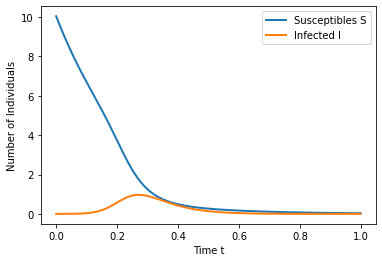

In [7]:
# Plot susceptibles and infected versus time

plt.plot(result[2],result[0],linewidth=2,label='Susceptibles S')
plt.plot(result[2],result[1],linewidth=2,label='Infected I')
plt.legend()
plt.xlabel('Time t')
plt.ylabel('Number of Individuals')
plt.show()

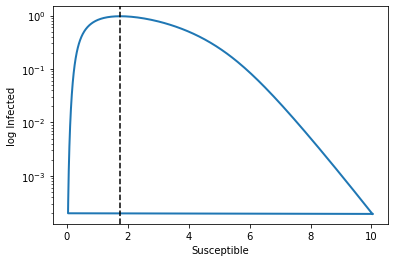

In [8]:
# Plotting in susceptible-infected plane

# Run simulation for longer than one period or add point to complete period
TotalS = np.append(result[0],result[0][0])
TotalI = np.append(result[1],result[1][0])

plt.plot(TotalS,TotalI,linewidth=2)
plt.xlabel('Susceptible')
plt.ylabel('log Infected')
plt.yscale('log')
plt.axvline(x=(d+mu)/Beta, color='black', linestyle='--')
plt.show()

## Hyperbolic Predation

Average infected for pulsed births: 0.607


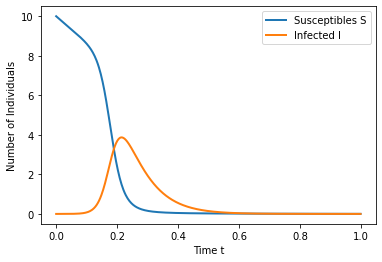

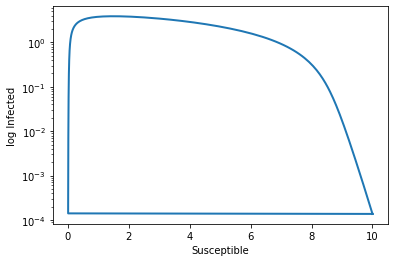

In [9]:
def deriv_y_hyp(t,y,Beta,mu,a,g,c):
  S,I = y
  dS = - Beta*I*S - a*S/(g+S+c*I)
  dI = Beta*I*S - mu*I - a*c*I/(g+S+c*I)
  return [dS,dI]


def solver_pulse_hyp(IC, b, Beta, mu, a, g, c):
    # Initialize storage arrays
    svals = np.array([])
    TotalS = np.array([])
    TotalI = np.array([])
    Total_time = np.array([])
    for i in range(0,2):
        if i == 0:
            year = 850
        else:
            year = period
            #year = 5 # Uncomment this line to run the simulation for longer than 1 period, note avg infection will be incorrect 
        for t in range(0,year):
            # Create time steps for one year
            time = np.linspace(t,t+1,500)
            time2 = [t,t+1]
            if i ==0 and t == 0:
                y0 = IC 
            else:
                # Add birth pulse
                y0 = [S[-1]+b,I[-1]]
            ysol = solve_ivp(deriv_y_hyp,time2,y0,method='Radau',args=(Beta,mu,a,g,c),dense_output=True,rtol=1e-13, atol=1e-323)
            S,I=ysol.sol(time)
            if t >= 800:
                # Track number of susceptibles at the start of each year, used to calculate period
                svals = np.append(svals,S[0])
            if t == 849:
                period = period_tracker(svals)
                if period == '>6':
                    TotalS = np.append(TotalS,S[-1])
                    TotalI = np.append(TotalI,I[-1])
                    return [TotalS,TotalI,Total_time,period]
            if i == 1:
                # Store solution for each year, remove overlapping time steps and solutions
                TotalS = np.append(TotalS,S[:-1])
                TotalI = np.append(TotalI,I[:-1])
                Total_time = np.append(Total_time,time[:-1])
    return [TotalS,TotalI,Total_time,period]


result = solver_pulse_hyp(initial_y0, b, Beta, mu, a, g, c)
if result[3] == '>6':
    print('Period greater than 6')
else:
    avg_infect = trapz(result[1],result[2])*(1/result[3])
    print('Average infected for pulsed births: '+str(round(avg_infect, 3)))

plt.plot(result[2],result[0],linewidth=2,label='Susceptibles S')
plt.plot(result[2],result[1],linewidth=2,label='Infected I')
plt.legend()
plt.xlabel('Time t')
plt.ylabel('Number of Individuals')
plt.show()

TotalS = np.append(result[0],result[0][0])
TotalI = np.append(result[1],result[1][0])

plt.plot(TotalS,TotalI,linewidth=2)
plt.xlabel('Susceptible')
plt.ylabel('log Infected')
plt.yscale('log')
plt.show()